In [ ]:
print("hola")

hola


In [2]:
pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00


In [3]:
# Verificar GPU y preparar librerías

import torch
import open_clip
import pandas as pd
import numpy as np

from pathlib import Path

# Dispositivo de cómputo
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("Dispositivo:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Dispositivo: cuda
GPU: Tesla T4


In [7]:
import os
from pathlib import Path
from google.colab import drive

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Ruta raíz general
drive_root = Path("/content/drive/MyDrive")

print("=" * 80)
print("📂 EXPLORACIÓN COMPLETA DE GOOGLE DRIVE (CARPETAS Y ARCHIVOS)")
print("=" * 80)

if drive_root.exists():
    print(f"Ruta raíz base: {drive_root}\n")

    for root, dirs, files in os.walk(drive_root):
        current_path = Path(root)

        # Filtrar elementos ocultos del sistema
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        files = [f for f in files if not f.startswith('.')]

        depth = len(current_path.relative_to(drive_root).parts)
        indent = "│   " * depth

        if depth == 0:
            print(f"📁 MyDrive/ ({current_path})")
        else:
            print(f"{indent}├── 📁 {current_path.name}/")

        # Imprimir todos los archivos dentro de cada carpeta
        for file in files:
            file_path = current_path / file
            try:
                # Tamaño en MB (o KB si es muy pequeño)
                size_bytes = file_path.stat().st_size
                if size_bytes >= 1024 * 1024:
                    size_str = f"{size_bytes / (1024 * 1024):.2f} MB"
                else:
                    size_str = f"{size_bytes / 1024:.1f} KB"
            except Exception:
                size_str = "tamaño no disponible"

            print(f"{indent}│   ├── 📄 {file} ({size_str})")

    print("\n" + "=" * 80)
    print("✅ Exploración completa finalizada exitosamente.")
else:
    print("❌ No se pudo acceder a Google Drive. Revisa la conexión del montaje.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 EXPLORACIÓN COMPLETA DE GOOGLE DRIVE (CARPETAS Y ARCHIVOS)
Ruta raíz base: /content/drive/MyDrive

📁 MyDrive/ (/content/drive/MyDrive)
│   ├── 📄 PROYECTO DE ASIGNATURA (1) (2).docx (9.60 MB)
│   ├── 📄 IMG_20250228_194910.jpg (2.09 MB)
│   ├── 📁 Colab Notebooks/
│   │   ├── 📄 ProyectVisionComputer.ipynb (275.7 KB)
│   │   ├── 📄 Untitled0.ipynb (0.3 KB)
│   │   ├── 📄 Copy of 01_eda_dataset.ipynb (7.51 MB)
│   │   ├── 📄 Copy of 02_prepare_split.ipynb (63.8 KB)
│   │   ├── 📄 Copy of 03_bioclip_zeroshot.ipynb (85.6 KB)
│   ├── 📁 dataset-LZUPSD/
│   │   ├── 📄 Seed dataset.zip (66.60 MB)
│   │   ├── 📁 prepared_1/
│   │   │   ├── 📄 train.csv (175.1 KB)
│   │   │   ├── 📄 val.csv (37.6 KB)
│   │   │   ├── 📄 test.csv (37.6 KB)
│   │   │   ├── 📄 excluded_images.csv (0.5 KB)
│   │   │   ├── 📄 config.json (3.4 KB)
│   │   ├── 📁 prepared_3/
│   │   │   ├── 📄 train.csv (17

In [10]:
import zipfile
from pathlib import Path

ZIP_PATH = Path(
    "/content/drive/MyDrive/dataset-LZUPSD/Seed dataset.zip"
)

EXTRACT_DIR = Path(
    "/content/Seed_dataset_extracted"
)

# Crear directorio de extracción
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extraer el dataset
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extracción completada.")
print("Directorio:", EXTRACT_DIR)
print("¿Existe?:", EXTRACT_DIR.exists())

Extracción completada.
Directorio: /content/Seed_dataset_extracted
¿Existe?: True


In [11]:
from pathlib import Path

EXTRACT_DIR = Path("/content/Seed_dataset_extracted")

print("Contenido de la extracción:")
for item in EXTRACT_DIR.iterdir():
    tipo = "📁" if item.is_dir() else "📄"
    print(f"{tipo} {item.name}")

Contenido de la extracción:
📁 Seed dataset


In [12]:
from pathlib import Path

DATASET_DIR = Path(
    "/content/Seed_dataset_extracted/Seed dataset"
)

# Buscar algunas imágenes
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

images = [
    path
    for path in DATASET_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in image_extensions
]

print("Directorio de imágenes:", DATASET_DIR)
print("¿Existe?:", DATASET_DIR.exists())
print("Cantidad de imágenes encontradas:", len(images))

print("\nPrimeras 5 imágenes:")
for image in images[:5]:
    print(" -", image.relative_to(DATASET_DIR))

Directorio de imágenes: /content/Seed_dataset_extracted/Seed dataset
¿Existe?: True
Cantidad de imágenes encontradas: 4496

Primeras 5 imágenes:
 - Apocynum venetum/changed3339.jpg
 - Apocynum venetum/changed3342.jpg
 - Apocynum venetum/changed3371.jpg
 - Apocynum venetum/changed3356.jpg
 - Apocynum venetum/changed3372.jpg


# **1. Cargar los splits**

In [13]:
import pandas as pd

# Cargar las particiones existentes
train_df = pd.read_csv(PREPARED_DIR / "train.csv")
val_df = pd.read_csv(PREPARED_DIR / "val.csv")
test_df = pd.read_csv(PREPARED_DIR / "test.csv")

# Mostrar información básica
print("Train:")
print("  Filas:", len(train_df))
print("  Columnas:", train_df.columns.tolist())

print("\nValidation:")
print("  Filas:", len(val_df))
print("  Columnas:", val_df.columns.tolist())

print("\nTest:")
print("  Filas:", len(test_df))
print("  Columnas:", test_df.columns.tolist())

print("\nTamaños esperados:")
print(f"  Train: {len(train_df)}")
print(f"  Val:   {len(val_df)}")
print(f"  Test:  {len(test_df)}")

print("\nPrimeras filas de train:")
display(train_df.head())

Train:
  Filas: 3145
  Columnas: ['image_path', 'class_name', 'class_id']

Validation:
  Filas: 674
  Columnas: ['image_path', 'class_name', 'class_id']

Test:
  Filas: 674
  Columnas: ['image_path', 'class_name', 'class_id']

Tamaños esperados:
  Train: 3145
  Val:   674
  Test:  674

Primeras filas de train:


,image_path,class_name,class_id
0,Thermopsis lanceolata/changed1308.jpg,Thermopsis lanceolata,81
1,Caragana microphylla/changed868.jpg,Caragana microphylla,25
2,Medicago lupulina/changed708.jpg,Medicago lupulina,62
3,Salsola tragus/changed259.jpg,Salsola tragus,77
4,Elymus pendulinus subsp. pubicaulis/changed182...,Elymus pendulinus subsp. pubicaulis,38


In [14]:
from pathlib import Path

def verify_image_paths(dataframe, dataset_dir):
    paths = [
        dataset_dir / image_path
        for image_path in dataframe["image_path"]
    ]

    missing = [
        path for path in paths
        if not path.exists()
    ]

    return paths, missing


# Verificar cada partición
train_paths, train_missing = verify_image_paths(train_df, DATASET_DIR)
val_paths, val_missing = verify_image_paths(val_df, DATASET_DIR)
test_paths, test_missing = verify_image_paths(test_df, DATASET_DIR)

print("Rutas inexistentes:")
print(f"  Train: {len(train_missing)}")
print(f"  Val:   {len(val_missing)}")
print(f"  Test:  {len(test_missing)}")

print("\nTotal de rutas inexistentes:",
      len(train_missing) + len(val_missing) + len(test_missing))

# Mostrar alguna ruta problemática si existe
if train_missing:
    print("\nEjemplo de ruta inexistente en train:")
    print(train_missing[0])
elif val_missing:
    print("\nEjemplo de ruta inexistente en val:")
    print(val_missing[0])
elif test_missing:
    print("\nEjemplo de ruta inexistente en test:")
    print(test_missing[0])
else:
    print("\n✅ Todas las rutas de los tres splits existen.")

Rutas inexistentes:
  Train: 0
  Val:   0
  Test:  0

Total de rutas inexistentes: 0

✅ Todas las rutas de los tres splits existen.


# **2. Carga de BioCLIP**

In [16]:
import torch
import open_clip

print("PyTorch:", torch.__version__)
print("OpenCLIP:", open_clip.__version__)
print("Dispositivo:", device)

PyTorch: 2.11.0+cu128
OpenCLIP: 3.3.0
Dispositivo: cuda


In [17]:
import open_clip

MODEL_ID = "hf-hub:imageomics/bioclip"

model, preprocess_train, preprocess_val = (
    open_clip.create_model_and_transforms(MODEL_ID)
)

tokenizer = open_clip.get_tokenizer(MODEL_ID)

model = model.to(device)
model.eval()

print("BioCLIP cargado correctamente.")
print("Modelo:", MODEL_ID)
print("Dispositivo:", next(model.parameters()).device)
print("Modo evaluación:", not model.training)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


open_clip_config.json:   0%|          | 0.00/469 [00:00<?, ?B/s]

open_clip_pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  599MB            

open_clip_pytorch_model.bin: downloading bytes:           |  0.00B            

BioCLIP cargado correctamente.
Modelo: hf-hub:imageomics/bioclip
Dispositivo: cuda:0
Modo evaluación: True


# **3. Crear el Dataset de Linear Probe**

In [18]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image


class SeedDataset(Dataset):
    """
    Dataset para cargar imágenes de semillas y sus etiquetas.

    Las rutas se obtienen directamente del CSV de cada partición.
    """

    def __init__(self, dataframe, dataset_dir, preprocess):
        self.dataframe = dataframe.reset_index(drop=True)
        self.dataset_dir = dataset_dir
        self.preprocess = preprocess

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = self.dataset_dir / row["image_path"]

        image = Image.open(image_path).convert("RGB")
        image = self.preprocess(image)

        label = int(row["class_id"])

        return image, label


# Crear datasets
train_dataset = SeedDataset(
    train_df,
    DATASET_DIR,
    preprocess_val
)

val_dataset = SeedDataset(
    val_df,
    DATASET_DIR,
    preprocess_val
)

test_dataset = SeedDataset(
    test_df,
    DATASET_DIR,
    preprocess_val
)

print("Datasets creados correctamente.")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Datasets creados correctamente.
Train: 3145
Validation: 674
Test: 674


# **4. Crear DataLoaders**

In [19]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoaders creados correctamente.")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

DataLoaders creados correctamente.
Train batches: 99
Validation batches: 22
Test batches: 22


***Prueba de un Batch antes de hacerlo en todos los demas***

In [20]:
images, labels = next(iter(train_loader))

print("Imágenes:")
print("  Shape:", images.shape)
print("  Dtype:", images.dtype)
print("  Device actual:", images.device)

print("\nEtiquetas:")
print("  Shape:", labels.shape)
print("  Dtype:", labels.dtype)

# Probar el encoder visual de BioCLIP
with torch.inference_mode():
    images_gpu = images.to(device, non_blocking=True)
    features = model.encode_image(images_gpu)

print("\nEmbeddings BioCLIP:")
print("  Shape:", features.shape)
print("  Dtype:", features.dtype)
print("  Device:", features.device)
print("  ¿Contiene NaN?:", torch.isnan(features).any().item())
print("  ¿Contiene Inf?:", torch.isinf(features).any().item())

Imágenes:
  Shape: torch.Size([32, 3, 224, 224])
  Dtype: torch.float32
  Device actual: cpu

Etiquetas:
  Shape: torch.Size([32])
  Dtype: torch.int64

Embeddings BioCLIP:
  Shape: torch.Size([32, 512])
  Dtype: torch.float32
  Device: cuda:0
  ¿Contiene NaN?: False
  ¿Contiene Inf?: False


# **Extracción de Embeddings**

In [21]:
import numpy as np
from tqdm.auto import tqdm


def extract_embeddings(model, dataloader, device):
    """
    Extrae embeddings visuales de BioCLIP y sus etiquetas.

    El orden de los embeddings coincide con el orden de los
    elementos del DataLoader.
    """
    model.eval()

    all_features = []
    all_labels = []

    with torch.inference_mode():
        for images, labels in tqdm(dataloader):
            images = images.to(device, non_blocking=True)

            features = model.encode_image(images)

            all_features.append(features.cpu())
            all_labels.append(labels)

    features = torch.cat(all_features, dim=0)
    labels = torch.cat(all_labels, dim=0)

    return features.numpy(), labels.numpy()


# Extraer embeddings
train_embeddings, train_labels = extract_embeddings(
    model,
    train_loader,
    device
)

val_embeddings, val_labels = extract_embeddings(
    model,
    val_loader,
    device
)

test_embeddings, test_labels = extract_embeddings(
    model,
    test_loader,
    device
)


print("\nExtracción completada.")

print("\nShapes:")
print("Train:", train_embeddings.shape, train_labels.shape)
print("Val:  ", val_embeddings.shape, val_labels.shape)
print("Test: ", test_embeddings.shape, test_labels.shape)

print("\n¿NaN?")
print("Train:", np.isnan(train_embeddings).any())
print("Val:  ", np.isnan(val_embeddings).any())
print("Test: ", np.isnan(test_embeddings).any())

print("\n¿Inf?")
print("Train:", np.isinf(train_embeddings).any())
print("Val:  ", np.isinf(val_embeddings).any())
print("Test: ", np.isinf(test_embeddings).any())

  0%|          | 0/99 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b2ec1d160c0>
Exception ignored in: Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7b2ec1d160c0>
    self._shutdown_workers()Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        if w.is_alive():
if w.is_alive():  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
assert self._parent_pid == os.getpid(), 'can only test a


Extracción completada.

Shapes:
Train: (3145, 512) (3145,)
Val:   (674, 512) (674,)
Test:  (674, 512) (674,)

¿NaN?
Train: False
Val:   False
Test:  False

¿Inf?
Train: False
Val:   False
Test:  False


In [22]:
print("Shapes:")
print("Train:", train_embeddings.shape, train_labels.shape)
print("Val:  ", val_embeddings.shape, val_labels.shape)
print("Test: ", test_embeddings.shape, test_labels.shape)

print("\n¿NaN?")
print("Train:", np.isnan(train_embeddings).any())
print("Val:  ", np.isnan(val_embeddings).any())
print("Test: ", np.isnan(test_embeddings).any())

print("\n¿Inf?")
print("Train:", np.isinf(train_embeddings).any())
print("Val:  ", np.isinf(val_embeddings).any())
print("Test: ", np.isinf(test_embeddings).any())

Shapes:
Train: (3145, 512) (3145,)
Val:   (674, 512) (674,)
Test:  (674, 512) (674,)

¿NaN?
Train: False
Val:   False
Test:  False

¿Inf?
Train: False
Val:   False
Test:  False


# **6. Guardar los Embeddings**

In [23]:
from pathlib import Path
import numpy as np

# Directorio de resultados de Linear Probe
LINEAR_PROBE_DIR = Path(
    "/content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs"
)

EMBEDDINGS_DIR = LINEAR_PROBE_DIR / "embeddings"

# Crear carpeta de embeddings
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

# Guardar embeddings
np.save(EMBEDDINGS_DIR / "train_embeddings.npy", train_embeddings)
np.save(EMBEDDINGS_DIR / "val_embeddings.npy", val_embeddings)
np.save(EMBEDDINGS_DIR / "test_embeddings.npy", test_embeddings)

# Guardar etiquetas
np.save(EMBEDDINGS_DIR / "train_labels.npy", train_labels)
np.save(EMBEDDINGS_DIR / "val_labels.npy", val_labels)
np.save(EMBEDDINGS_DIR / "test_labels.npy", test_labels)

print("Embeddings guardados correctamente.")
print("Directorio:", EMBEDDINGS_DIR)

print("\nArchivos:")
for file in sorted(EMBEDDINGS_DIR.iterdir()):
    print(" -", file.name)

Embeddings guardados correctamente.
Directorio: /content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs/embeddings

Archivos:
 - test_embeddings.npy
 - test_labels.npy
 - train_embeddings.npy
 - train_labels.npy
 - val_embeddings.npy
 - val_labels.npy


# **7. Comprobar clases**

In [24]:
import numpy as np

train_classes = np.unique(train_labels)
val_classes = np.unique(val_labels)
test_classes = np.unique(test_labels)

print("Número de clases:")
print("  Train:", len(train_classes))
print("  Val:  ", len(val_classes))
print("  Test: ", len(test_classes))

print("\nIDs de clase:")
print("  Train:", train_classes)
print("  Val:  ", val_classes)
print("  Test: ", test_classes)

print("\n¿Mismos IDs en los tres splits?:",
      np.array_equal(train_classes, val_classes)
      and np.array_equal(train_classes, test_classes))

Número de clases:
  Train: 88
  Val:   88
  Test:  88

IDs de clase:
  Train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87]
  Val:   [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87]
  Test:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87]

¿Mismos IDs en los tres splits?: True


# **8. Entrenar Linear Probe**

In [25]:
import sklearn

from sklearn.linear_model import LogisticRegression

print("scikit-learn:", sklearn.__version__)
print("Modelo del Linear Probe:", LogisticRegression.__name__)
print("Dimensión de entrada:", train_embeddings.shape[1])
print("Número de clases:", len(np.unique(train_labels)))

scikit-learn: 1.6.1
Modelo del Linear Probe: LogisticRegression
Dimensión de entrada: 512
Número de clases: 88


In [26]:
linear_probe = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print(linear_probe)

LogisticRegression(max_iter=1000, random_state=42)


In [27]:
import time

# Entrenando Linear Probe

start_time = time.time()

linear_probe.fit(
    train_embeddings,
    train_labels
)

elapsed_time = time.time() - start_time

print("\nEntrenamiento completado.")
print(f"Tiempo de entrenamiento: {elapsed_time:.2f} segundos")
print(f"Número de iteraciones realizadas: {linear_probe.n_iter_}")
print(f"¿Convergió?: {linear_probe.n_iter_.max() < linear_probe.max_iter}")


Entrenamiento completado.
Tiempo de entrenamiento: 6.19 segundos
Número de iteraciones realizadas: [61]
¿Convergió?: True


# **9. Métricas de evaluación (validation)**

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Predicciones sobre validation
val_predictions = linear_probe.predict(val_embeddings)

# Métricas
val_accuracy = accuracy_score(val_labels, val_predictions)

val_precision_macro = precision_score(
    val_labels,
    val_predictions,
    average="macro",
    zero_division=0
)

val_recall_macro = recall_score(
    val_labels,
    val_predictions,
    average="macro",
    zero_division=0
)

val_f1_macro = f1_score(
    val_labels,
    val_predictions,
    average="macro",
    zero_division=0
)

val_f1_weighted = f1_score(
    val_labels,
    val_predictions,
    average="weighted",
    zero_division=0
)

val_confusion = confusion_matrix(
    val_labels,
    val_predictions
)

val_report = classification_report(
    val_labels,
    val_predictions,
    zero_division=0
)

print("=== Linear Probe — Validation ===")
print(f"Accuracy:          {val_accuracy:.4f}")
print(f"Precision macro:   {val_precision_macro:.4f}")
print(f"Recall macro:      {val_recall_macro:.4f}")
print(f"F1 macro:          {val_f1_macro:.4f}")
print(f"F1 weighted:       {val_f1_weighted:.4f}")

print("\nMatriz de confusión:", val_confusion.shape)

print("\nClassification Report:")
print(val_report)

=== Linear Probe — Validation ===
Accuracy:          0.8769
Precision macro:   0.8958
Recall macro:      0.8742
F1 macro:          0.8769
F1 weighted:       0.8760

Matriz de confusión: (88, 88)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      0.71      0.83         7
           2       0.87      1.00      0.93        13
           3       0.67      0.67      0.67         9
           4       0.80      0.80      0.80         5
           5       0.80      0.57      0.67         7
           6       1.00      1.00      1.00         6
           7       1.00      1.00      1.00         6
           8       1.00      0.71      0.83         7
           9       1.00      1.00      1.00         7
          10       0.78      1.00      0.88         7
          11       0.80      0.57      0.67         7
          12       0.60      0.86      0.71         7
          13       0.82 

## **9.1 Métricas en test**

In [29]:
# Predicciones finales sobre el conjunto de test
test_predictions = linear_probe.predict(test_embeddings)

# Métricas
test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_precision_macro = precision_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

test_recall_macro = recall_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

test_f1_macro = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

test_f1_weighted = f1_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_confusion = confusion_matrix(
    test_labels,
    test_predictions
)

test_report = classification_report(
    test_labels,
    test_predictions,
    zero_division=0
)

print("=== Linear Probe — Test ===")
print(f"Accuracy:          {test_accuracy:.4f}")
print(f"Precision macro:   {test_precision_macro:.4f}")
print(f"Recall macro:      {test_recall_macro:.4f}")
print(f"F1 macro:          {test_f1_macro:.4f}")
print(f"F1 weighted:       {test_f1_weighted:.4f}")

print("\nMatriz de confusión:", test_confusion.shape)

print("\nClassification Report:")
print(test_report)

=== Linear Probe — Test ===
Accuracy:          0.9036
Precision macro:   0.9143
Recall macro:      0.8988
F1 macro:          0.8992
F1 weighted:       0.9032

Matriz de confusión: (88, 88)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       1.00      0.83      0.91         6
           2       0.93      1.00      0.96        13
           3       0.71      0.62      0.67         8
           4       0.71      0.83      0.77         6
           5       1.00      1.00      1.00         7
           6       1.00      0.83      0.91         6
           7       1.00      1.00      1.00         6
           8       1.00      1.00      1.00         7
           9       1.00      0.71      0.83         7
          10       0.88      1.00      0.93         7
          11       0.78      1.00      0.88         7
          12       0.88      1.00      0.93         7
          13       1.00      0

# **10. Guardar los resultados de Linear Probe**

In [30]:
# ============================================================
# Guardar resultados finales del Linear Probe
# ============================================================

from pathlib import Path
import json
import pandas as pd
import numpy as np

# Directorio de salida
LINEAR_PROBE_DIR = Path(
    "/content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs"
)
LINEAR_PROBE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Predicciones detalladas sobre test
# ------------------------------------------------------------

test_results_df = test_df.copy()

test_results_df["predicted_class_id"] = test_predictions

# Mapeo class_id -> class_name
id_to_class = (
    train_df[["class_id", "class_name"]]
    .drop_duplicates()
    .set_index("class_id")["class_name"]
    .to_dict()
)

test_results_df["predicted_class_name"] = (
    test_results_df["predicted_class_id"].map(id_to_class)
)

test_results_path = LINEAR_PROBE_DIR / "test_predictions.csv"
test_results_df.to_csv(test_results_path, index=False)

# ------------------------------------------------------------
# 2. Métricas
# ------------------------------------------------------------

metrics = {
    "experiment": "Linear Probe",
    "model": "BioCLIP ViT-B/16",
    "strategy": "Frozen visual encoder + Logistic Regression",
    "test_samples": int(len(test_labels)),
    "num_classes": int(len(np.unique(test_labels))),
    "accuracy": float(test_accuracy),
    "precision_macro": float(test_precision_macro),
    "recall_macro": float(test_recall_macro),
    "f1_macro": float(test_f1_macro),
    "f1_weighted": float(test_f1_weighted)
}

metrics_path = LINEAR_PROBE_DIR / "test_metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

# ------------------------------------------------------------
# 3. Matriz de confusión
# ------------------------------------------------------------

confusion_path = LINEAR_PROBE_DIR / "test_confusion_matrix.npy"
np.save(confusion_path, test_confusion)

# ------------------------------------------------------------
# 4. Classification report
# ------------------------------------------------------------

report_dict = classification_report(
    test_labels,
    test_predictions,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_path = LINEAR_PROBE_DIR / "test_classification_report.csv"
report_df.to_csv(report_path)

# ------------------------------------------------------------
# 5. Resumen
# ------------------------------------------------------------

print("Resultados guardados correctamente:")
print(f"- Predicciones:        {test_results_path}")
print(f"- Métricas:            {metrics_path}")
print(f"- Matriz de confusión: {confusion_path}")
print(f"- Classification report: {report_path}")

print("\nResumen:")
print(f"Accuracy:        {test_accuracy:.4f}")
print(f"Precision macro: {test_precision_macro:.4f}")
print(f"Recall macro:    {test_recall_macro:.4f}")
print(f"F1 macro:        {test_f1_macro:.4f}")
print(f"F1 weighted:     {test_f1_weighted:.4f}")# ============================================================
# Guardar resultados finales del Linear Probe
# ============================================================

from pathlib import Path
import json
import pandas as pd
import numpy as np

# Directorio de salida
LINEAR_PROBE_DIR = Path(
    "/content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs"
)
LINEAR_PROBE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Predicciones detalladas sobre test
# ------------------------------------------------------------

test_results_df = test_df.copy()

test_results_df["predicted_class_id"] = test_predictions

# Mapeo class_id -> class_name
id_to_class = (
    train_df[["class_id", "class_name"]]
    .drop_duplicates()
    .set_index("class_id")["class_name"]
    .to_dict()
)

test_results_df["predicted_class_name"] = (
    test_results_df["predicted_class_id"].map(id_to_class)
)

test_results_path = LINEAR_PROBE_DIR / "test_predictions.csv"
test_results_df.to_csv(test_results_path, index=False)

# ------------------------------------------------------------
# 2. Métricas
# ------------------------------------------------------------

metrics = {
    "experiment": "Linear Probe",
    "model": "BioCLIP ViT-B/16",
    "strategy": "Frozen visual encoder + Logistic Regression",
    "test_samples": int(len(test_labels)),
    "num_classes": int(len(np.unique(test_labels))),
    "accuracy": float(test_accuracy),
    "precision_macro": float(test_precision_macro),
    "recall_macro": float(test_recall_macro),
    "f1_macro": float(test_f1_macro),
    "f1_weighted": float(test_f1_weighted)
}

metrics_path = LINEAR_PROBE_DIR / "test_metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

# ------------------------------------------------------------
# 3. Matriz de confusión
# ------------------------------------------------------------

confusion_path = LINEAR_PROBE_DIR / "test_confusion_matrix.npy"
np.save(confusion_path, test_confusion)

# ------------------------------------------------------------
# 4. Classification report
# ------------------------------------------------------------

report_dict = classification_report(
    test_labels,
    test_predictions,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_path = LINEAR_PROBE_DIR / "test_classification_report.csv"
report_df.to_csv(report_path)

# ------------------------------------------------------------
# 5. Resumen
# ------------------------------------------------------------

print("Resultados guardados correctamente:")
print(f"- Predicciones:        {test_results_path}")
print(f"- Métricas:            {metrics_path}")
print(f"- Matriz de confusión: {confusion_path}")
print(f"- Classification report: {report_path}")

print("\nResumen:")
print(f"Accuracy:        {test_accuracy:.4f}")
print(f"Precision macro: {test_precision_macro:.4f}")
print(f"Recall macro:    {test_recall_macro:.4f}")
print(f"F1 macro:        {test_f1_macro:.4f}")
print(f"F1 weighted:     {test_f1_weighted:.4f}")

Resultados guardados correctamente:
- Predicciones:        /content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs/test_predictions.csv
- Métricas:            /content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs/test_metrics.json
- Matriz de confusión: /content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs/test_confusion_matrix.npy
- Classification report: /content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs/test_classification_report.csv

Resumen:
Accuracy:        0.9036
Precision macro: 0.9143
Recall macro:    0.8988
F1 macro:        0.8992
F1 weighted:     0.9032
Resultados guardados correctamente:
- Predicciones:        /content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs/test_predictions.csv
- Métricas:            /content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs/test_metrics.json
- Matriz de confusión: /content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs/test_confusion_matrix.npy
- Classification report: /content/drive/MyDrive/dataset-LZUPS

# **11. BioCLIP Zero-Shot vs. Linear Probe**

In [31]:
comparison_df = pd.DataFrame([
    {
        "Experimento": "BioCLIP Zero-Shot",
        "Estrategia": "Imagen + texto, sin entrenamiento",
        "Accuracy": 0.0208,
        "Precision macro": 0.0105,
        "Recall macro": 0.0219,
        "F1 macro": 0.0119,
        "F1 weighted": 0.0123,
        "Top-3 Accuracy": 0.0564
    },
    {
        "Experimento": "Linear Probe",
        "Estrategia": "Encoder congelado + Logistic Regression",
        "Accuracy": test_accuracy,
        "Precision macro": test_precision_macro,
        "Recall macro": test_recall_macro,
        "F1 macro": test_f1_macro,
        "F1 weighted": test_f1_weighted,
        "Top-3 Accuracy": np.nan
    }
])

print("=== Comparación BioCLIP ===")
display(comparison_df)


zero_shot_accuracy = 0.0208
zero_shot_f1_macro = 0.0119
zero_shot_f1_weighted = 0.0123

accuracy_improvement = test_accuracy - zero_shot_accuracy
f1_macro_improvement = test_f1_macro - zero_shot_f1_macro
f1_weighted_improvement = test_f1_weighted - zero_shot_f1_weighted

print("\n=== Mejora absoluta ===")
print(f"Accuracy:     +{accuracy_improvement:.4f}")
print(f"F1 macro:     +{f1_macro_improvement:.4f}")
print(f"F1 weighted:  +{f1_weighted_improvement:.4f}")

=== Comparación BioCLIP ===


,Experimento,Estrategia,Accuracy,Precision macro,Recall macro,F1 macro,F1 weighted,Top-3 Accuracy
0,BioCLIP Zero-Shot,"Imagen + texto, sin entrenamiento",0.020800,0.010500,0.021900,0.011900,0.012300,0.0564
1,Linear Probe,Encoder congelado + Logistic Regression,0.903561,0.914293,0.898793,0.899227,0.903197,NaN



=== Mejora absoluta ===
Accuracy:     +0.8828
F1 macro:     +0.8873
F1 weighted:  +0.8909


# **12. Gráficas de desempeño**

In [32]:

# Obtener métricas por clase
per_class_report = pd.DataFrame(
    classification_report(
        test_labels,
        test_predictions,
        output_dict=True,
        zero_division=0
    )
).transpose()

# Mantener únicamente las clases
class_ids = [str(i) for i in sorted(np.unique(test_labels))]

worst_classes = per_class_report.loc[
    per_class_report.index.isin(class_ids),
    ["precision", "recall", "f1-score", "support"]
].copy()

# Convertir class_id a entero
worst_classes.index = worst_classes.index.astype(int)

# Añadir nombre de la especie
worst_classes["class_name"] = worst_classes.index.map(id_to_class)

# Ordenar por F1 ascendente
worst_classes = worst_classes.sort_values(
    by=["f1-score", "recall"],
    ascending=[True, True]
)

# Mostrar las 10 clases con menor desempeño
worst_10 = worst_classes.head(10).copy()

print("=== 10 clases con menor F1-score ===")

display(
    worst_10[
        [
            "class_name",
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ].style.format({
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1-score": "{:.3f}",
        "support": "{:.0f}"
    })
)

=== 10 clases con menor F1-score ===


,class_name,precision,recall,f1-score,support
43,Halogeton arachnoideus,0.500,0.429,0.462,7
59,Lycium chinese,0.750,0.375,0.500,8
51,Kochia scoparia,0.455,0.625,0.526,8
3,Agropyron cristatum,0.714,0.625,0.667,8
14,Astragalus laxmannii,0.667,0.667,0.667,6
57,Limonium aureum,0.625,0.714,0.667,7
60,Lycium ruthenicum,0.538,0.875,0.667,8
52,Leonurus japonicus,0.714,0.714,0.714,7
24,Caragana liouana,0.625,0.833,0.714,6
79,Setaria viridis,1.000,0.571,0.727,7


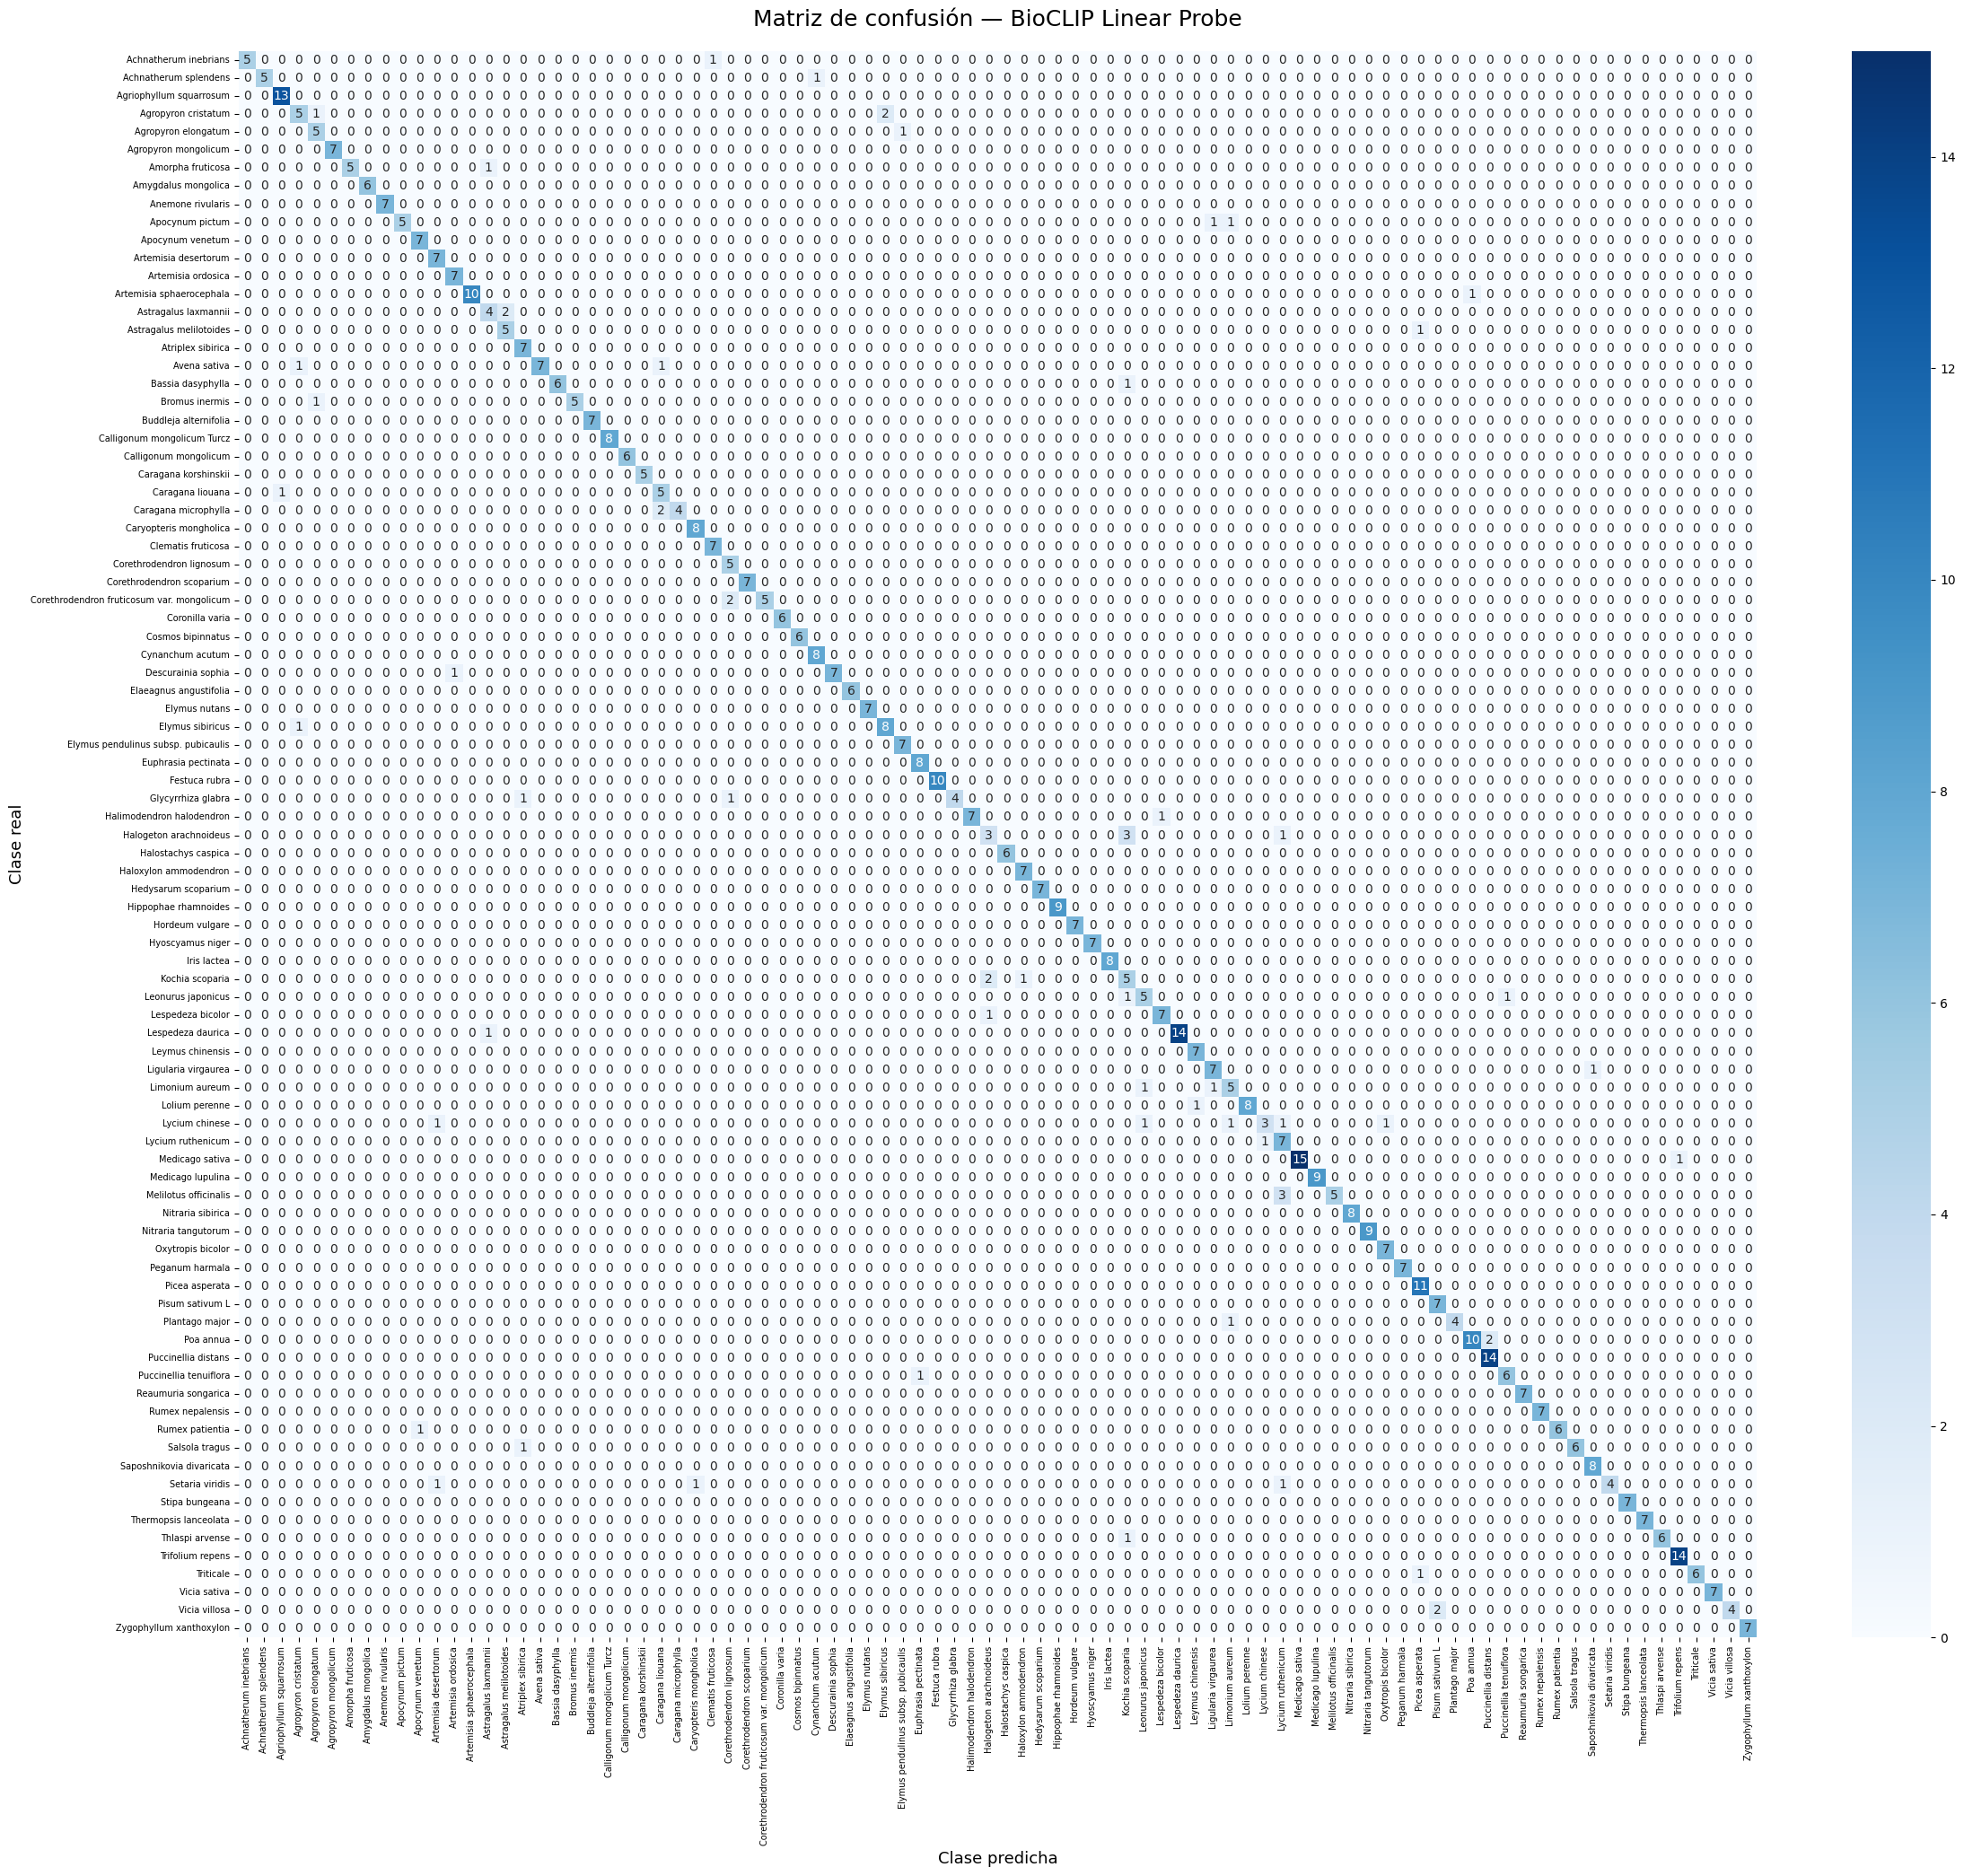

Figura guardada en:
/content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs/test_confusion_matrix.png


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener nombres ordenados por class_id
class_names = [
    id_to_class[class_id]
    for class_id in sorted(id_to_class.keys())
]

plt.figure(figsize=(24, 21))

sns.heatmap(
    test_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

plt.title(
    "Matriz de confusión — BioCLIP Linear Probe",
    fontsize=18,
    pad=20
)

plt.xlabel("Clase predicha", fontsize=13)
plt.ylabel("Clase real", fontsize=13)

plt.xticks(
    rotation=90,
    fontsize=7
)

plt.yticks(
    rotation=0,
    fontsize=7
)

plt.tight_layout()

# Guardar figura
confusion_fig_path = (
    LINEAR_PROBE_DIR / "test_confusion_matrix.png"
)

plt.savefig(
    confusion_fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figura guardada en:")
print(confusion_fig_path)

In [34]:
confusion_pairs = []

for true_id in range(test_confusion.shape[0]):
    for pred_id in range(test_confusion.shape[1]):

        # Ignorar la diagonal: aciertos
        if true_id != pred_id and test_confusion[true_id, pred_id] > 0:
            confusion_pairs.append({
                "true_id": true_id,
                "pred_id": pred_id,
                "true_class": id_to_class[true_id],
                "pred_class": id_to_class[pred_id],
                "errors": int(test_confusion[true_id, pred_id])
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs)

confusion_pairs_df = confusion_pairs_df.sort_values(
    "errors",
    ascending=False
).reset_index(drop=True)

print("=== 15 confusiones más frecuentes ===\n")

for i, row in confusion_pairs_df.head(15).iterrows():
    print(
        f"{i + 1:2d}. "
        f"{row['true_class']} → {row['pred_class']} "
        f"({row['errors']} error(es))"
    )


# ------------------------------------------------------------
# 2. Confusiones de las 10 clases con menor F1
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("=== Confusiones de las 10 clases con menor F1-score ===")
print("=" * 75)

for true_id in worst_10.index:

    row_confusion = test_confusion[true_id].copy()

    # Ignorar el acierto de la diagonal
    row_confusion[true_id] = 0

    confused_ids = np.argsort(row_confusion)[::-1]

    # Conservar únicamente clases con al menos un error
    confused_ids = [
        pred_id
        for pred_id in confused_ids
        if row_confusion[pred_id] > 0
    ]

    class_name = id_to_class[true_id]

    print(f"\n{class_name} (clase {true_id})")

    if not confused_ids:
        print("  No presenta errores de clasificación.")
        continue

    for pred_id in confused_ids[:3]:
        errors = int(row_confusion[pred_id])

        print(
            f"  → {id_to_class[pred_id]}: "
            f"{errors} error(es)"
        )

=== 15 confusiones más frecuentes ===

 1. Melilotus officinalis → Lycium ruthenicum (3 error(es))
 2. Halogeton arachnoideus → Kochia scoparia (3 error(es))
 3. Corethrodendron fruticosum var. mongolicum → Corethrodendron lignosum (2 error(es))
 4. Caragana microphylla → Caragana liouana (2 error(es))
 5. Agropyron cristatum → Elymus sibiricus (2 error(es))
 6. Astragalus laxmannii → Astragalus melilotoides (2 error(es))
 7. Kochia scoparia → Halogeton arachnoideus (2 error(es))
 8. Poa annua → Puccinellia distans (2 error(es))
 9. Vicia villosa → Pisum sativum L (2 error(es))
10. Agropyron cristatum → Agropyron elongatum (1 error(es))
11. Amorpha fruticosa → Astragalus laxmannii (1 error(es))
12. Agropyron elongatum → Elymus pendulinus subsp. pubicaulis (1 error(es))
13. Apocynum pictum → Limonium aureum (1 error(es))
14. Artemisia sphaerocephala → Poa annua (1 error(es))
15. Bassia dasyphylla → Kochia scoparia (1 error(es))

=== Confusiones de las 10 clases con menor F1-score ===

H

# **11. Comprobación de cuántos parámetros tiene BioCLIP y cuántos parámetros se entrenaron realmente**

In [37]:
# Congelar todos los parámetros de BioCLIP
for param in model.parameters():
    param.requires_grad = False

model.eval()

# Recalcular parámetros
total_bioclip_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_bioclip_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_bioclip_params = (
    total_bioclip_params - trainable_bioclip_params
)

# Parámetros del clasificador
logistic_coef_params = linear_probe.coef_.size
logistic_intercept_params = linear_probe.intercept_.size

linear_probe_params = (
    logistic_coef_params +
    logistic_intercept_params
)

print("=== Estado final del Linear Probe ===\n")

print("BioCLIP")
print(f"Parámetros totales:      {total_bioclip_params:,}")
print(f"Parámetros entrenables:  {trainable_bioclip_params:,}")
print(f"Parámetros congelados:   {frozen_bioclip_params:,}")

print("\nLogistic Regression")
print(f"Parámetros de coeficientes: {logistic_coef_params:,}")
print(f"Parámetros de intercepto:   {logistic_intercept_params:,}")
print(f"Total aprendido:            {linear_probe_params:,}")

print("\n=== Proporción del modelo que fue aprendida ===")

learned_percentage = (
    linear_probe_params /
    total_bioclip_params
) * 100

print(
    f"Parámetros aprendidos / parámetros de BioCLIP: "
    f"{learned_percentage:.6f}%"
)

=== Estado final del Linear Probe ===

BioCLIP
Parámetros totales:      149,620,737
Parámetros entrenables:  0
Parámetros congelados:   149,620,737

Logistic Regression
Parámetros de coeficientes: 45,056
Parámetros de intercepto:   88
Total aprendido:            45,144

=== Proporción del modelo que fue aprendida ===
Parámetros aprendidos / parámetros de BioCLIP: 0.030172%


# **12. Guardar resumen de parámetros**

In [39]:
from pathlib import Path
import json

# Carpeta de resultados de Linear Probe
OUTPUT_DIR = Path(
    "/content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

parameter_summary = {
    "experiment": "Linear Probe",
    "model": "BioCLIP ViT-B/16",
    "strategy": "Frozen BioCLIP visual encoder + Logistic Regression",

    "bioclip_total_parameters": int(total_bioclip_params),
    "bioclip_trainable_parameters": int(trainable_bioclip_params),
    "bioclip_frozen_parameters": int(frozen_bioclip_params),

    "classifier": "Logistic Regression",
    "classifier_weight_parameters": int(logistic_coef_params),
    "classifier_bias_parameters": int(logistic_intercept_params),
    "classifier_total_parameters": int(linear_probe_params),

    "embedding_dimension": int(train_embeddings.shape[1]),
    "num_classes": int(len(np.unique(train_labels))),

    "learned_percentage_relative_to_bioclip": float(learned_percentage)
}

PARAMETERS_PATH = OUTPUT_DIR / "linear_probe_parameter_summary.json"

with open(PARAMETERS_PATH, "w", encoding="utf-8") as f:
    json.dump(parameter_summary, f, indent=4, ensure_ascii=False)

print("Resumen de parámetros guardado correctamente.")
print(f"Ruta: {PARAMETERS_PATH}")

Resumen de parámetros guardado correctamente.
Ruta: /content/drive/MyDrive/dataset-LZUPSD/linear_probe_outputs/linear_probe_parameter_summary.json
